# Supervised Learning (Regresi) Harga Rumah
Dataset: King County House Sales (Washington, USA)  
Target: `price`  
Model: Linear Regression & Decision Tree Regressor

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import joblib
import warnings
warnings.filterwarnings('ignore')

## 1. Load & Eksplorasi Data

In [2]:
df = pd.read_csv('data.csv')
print('Shape:', df.shape)
df.head()

Shape: (4600, 18)


,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,street,city,statezip,country
0,2014-05-02 00:00:00,313000.0,3.0,1.50,1340,7912,1.5,0,0,3,1340,0,1955,2005,18810 Densmore Ave N,Shoreline,WA 98133,USA
1,2014-05-02 00:00:00,2384000.0,5.0,2.50,3650,9050,2.0,0,4,5,3370,280,1921,0,709 W Blaine St,Seattle,WA 98119,USA
2,2014-05-02 00:00:00,342000.0,3.0,2.00,1930,11947,1.0,0,0,4,1930,0,1966,0,26206-26214 143rd Ave SE,Kent,WA 98042,USA
3,2014-05-02 00:00:00,420000.0,3.0,2.25,2000,8030,1.0,0,0,4,1000,1000,1963,0,857 170th Pl NE,Bellevue,WA 98008,USA
4,2014-05-02 00:00:00,550000.0,4.0,2.50,1940,10500,1.0,0,0,4,1140,800,1976,1992,9105 170th Ave NE,Redmond,WA 98052,USA


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4600 entries, 0 to 4599
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   date           4600 non-null   str    
 1   price          4600 non-null   float64
 2   bedrooms       4600 non-null   float64
 3   bathrooms      4600 non-null   float64
 4   sqft_living    4600 non-null   int64  
 5   sqft_lot       4600 non-null   int64  
 6   floors         4600 non-null   float64
 7   waterfront     4600 non-null   int64  
 8   view           4600 non-null   int64  
 9   condition      4600 non-null   int64  
 10  sqft_above     4600 non-null   int64  
 11  sqft_basement  4600 non-null   int64  
 12  yr_built       4600 non-null   int64  
 13  yr_renovated   4600 non-null   int64  
 14  street         4600 non-null   str    
 15  city           4600 non-null   str    
 16  statezip       4600 non-null   str    
 17  country        4600 non-null   str    
dtypes: float64(4), int6

In [4]:
df.describe()

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated
count,4.600000e+03,4600.000000,4600.000000,4600.000000,4.600000e+03,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000
mean,5.519630e+05,3.400870,2.160815,2139.346957,1.485252e+04,1.512065,0.007174,0.240652,3.451739,1827.265435,312.081522,1970.786304,808.608261
std,5.638347e+05,0.908848,0.783781,963.206916,3.588444e+04,0.538288,0.084404,0.778405,0.677230,862.168977,464.137228,29.731848,979.414536
min,0.000000e+00,0.000000,0.000000,370.000000,6.380000e+02,1.000000,0.000000,0.000000,1.000000,370.000000,0.000000,1900.000000,0.000000
25%,3.228750e+05,3.000000,1.750000,1460.000000,5.000750e+03,1.000000,0.000000,0.000000,3.000000,1190.000000,0.000000,1951.000000,0.000000
50%,4.609435e+05,3.000000,2.250000,1980.000000,7.683000e+03,1.500000,0.000000,0.000000,3.000000,1590.000000,0.000000,1976.000000,0.000000
75%,6.549625e+05,4.000000,2.500000,2620.000000,1.100125e+04,2.000000,0.000000,0.000000,4.000000,2300.000000,610.000000,1997.000000,1999.000000
max,2.659000e+07,9.000000,8.000000,13540.000000,1.074218e+06,3.500000,1.000000,4.000000,5.000000,9410.000000,4820.000000,2014.000000,2014.000000


In [5]:
print('Missing values:')
print(df.isnull().sum())

Missing values:
date             0
price            0
bedrooms         0
bathrooms        0
sqft_living      0
sqft_lot         0
floors           0
waterfront       0
view             0
condition        0
sqft_above       0
sqft_basement    0
yr_built         0
yr_renovated     0
street           0
city             0
statezip         0
country          0
dtype: int64


## 2. Preprocessing

In [6]:
FEATURES = [
    'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot',
    'floors', 'waterfront', 'view', 'condition',
    'sqft_above', 'sqft_basement', 'yr_built', 'yr_renovated'
]
TARGET = 'price'

# Pilih kolom relevan dan hapus baris dengan NaN
data = df[FEATURES + [TARGET]].dropna()
print('Data setelah dropna:', data.shape)

X = data[FEATURES]
y = data[TARGET]
print('\nDistribusi target (price):')
print(y.describe())

Data setelah dropna: (4600, 13)

Distribusi target (price):
count    4.600000e+03
mean     5.519630e+05
std      5.638347e+05
min      0.000000e+00
25%      3.228750e+05
50%      4.609435e+05
75%      6.549625e+05
max      2.659000e+07
Name: price, dtype: float64


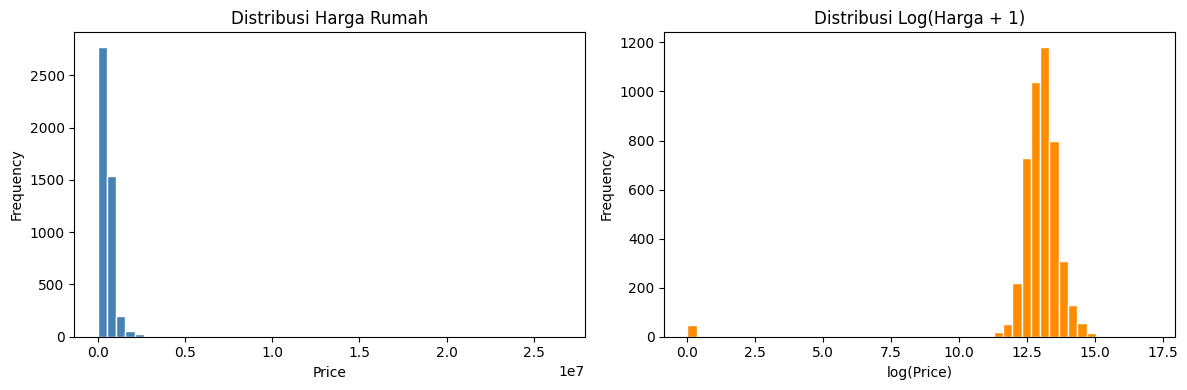

In [7]:
# Visualisasi distribusi harga
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(y, bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Distribusi Harga Rumah')
axes[0].set_xlabel('Price')
axes[0].set_ylabel('Frequency')

axes[1].hist(np.log1p(y), bins=50, color='darkorange', edgecolor='white')
axes[1].set_title('Distribusi Log(Harga + 1)')
axes[1].set_xlabel('log(Price)')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

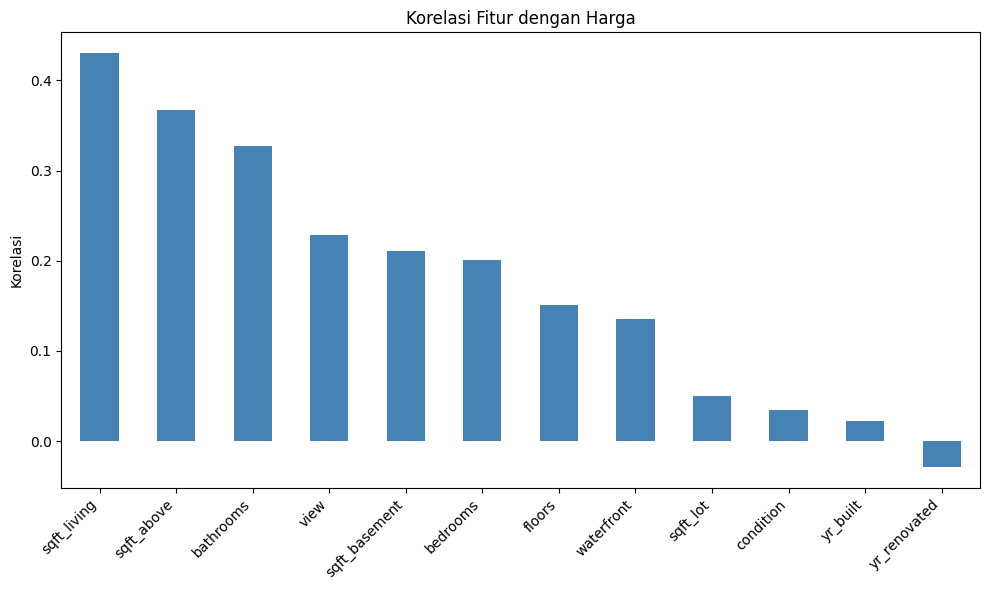

In [8]:
# Korelasi fitur dengan harga
plt.figure(figsize=(10, 6))
corr = data.corr()[TARGET].drop(TARGET).sort_values(ascending=False)
corr.plot(kind='bar', color='steelblue')
plt.title('Korelasi Fitur dengan Harga')
plt.ylabel('Korelasi')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [9]:
# Train-test split 80:20
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f'Train size: {X_train.shape[0]}')
print(f'Test  size: {X_test.shape[0]}')

Train size: 3680
Test  size: 920


## 3. Model 1 - Linear Regression

In [10]:
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

y_pred_lr = lr_model.predict(X_test)

mae_lr  = mean_absolute_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2_lr   = r2_score(y_test, y_pred_lr)

print('=== Linear Regression ===')
print(f'MAE  : {mae_lr:,.2f}')
print(f'RMSE : {rmse_lr:,.2f}')
print(f'R2   : {r2_lr:.4f}')

=== Linear Regression ===
MAE  : 210,908.17
RMSE : 993,439.36
R2   : 0.0323


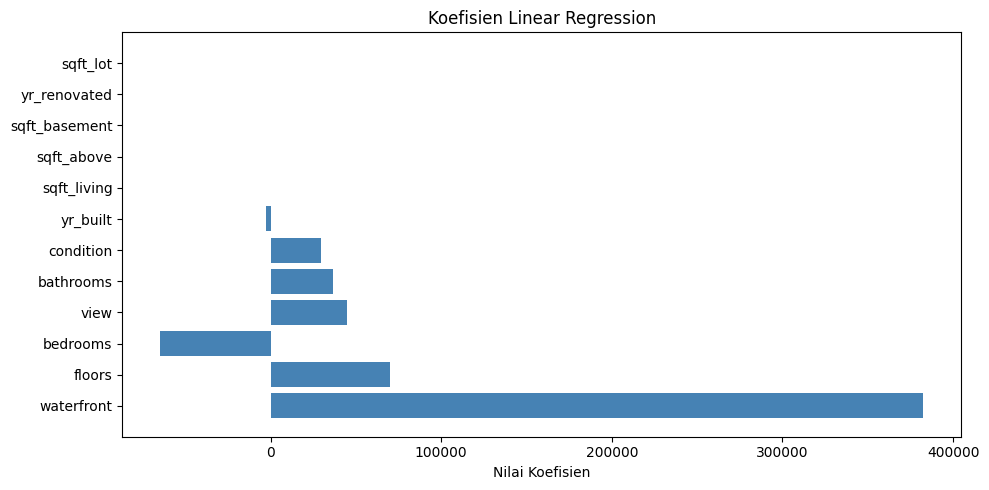

,Feature,Coefficient
5,waterfront,382459.666353
4,floors,69824.740108
0,bedrooms,-64497.461587
6,view,44755.841775
1,bathrooms,36520.440676
7,condition,29335.539392
10,yr_built,-2569.163533
2,sqft_living,186.049845
8,sqft_above,96.860817
9,sqft_basement,89.189028


In [11]:
# Koefisien regresi
coef_df = pd.DataFrame({
    'Feature': FEATURES,
    'Coefficient': lr_model.coef_
}).sort_values('Coefficient', key=abs, ascending=False)

plt.figure(figsize=(10, 5))
plt.barh(coef_df['Feature'], coef_df['Coefficient'], color='steelblue')
plt.title('Koefisien Linear Regression')
plt.xlabel('Nilai Koefisien')
plt.tight_layout()
plt.show()

coef_df

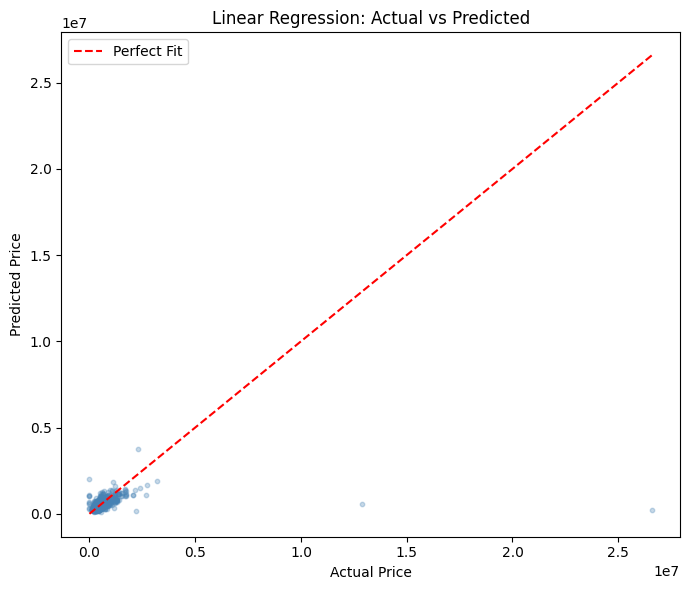

In [12]:
# Actual vs Predicted
plt.figure(figsize=(7, 6))
plt.scatter(y_test, y_pred_lr, alpha=0.3, color='steelblue', s=10)
lims = [y_test.min(), y_test.max()]
plt.plot(lims, lims, 'r--', linewidth=1.5, label='Perfect Fit')
plt.title('Linear Regression: Actual vs Predicted')
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.legend()
plt.tight_layout()
plt.show()

## 4. Model 2 - Decision Tree Regressor

In [13]:
dt_model = DecisionTreeRegressor(max_depth=6, min_samples_leaf=10, random_state=42)
dt_model.fit(X_train, y_train)

y_pred_dt = dt_model.predict(X_test)

mae_dt  = mean_absolute_error(y_test, y_pred_dt)
rmse_dt = np.sqrt(mean_squared_error(y_test, y_pred_dt))
r2_dt   = r2_score(y_test, y_pred_dt)

print('=== Decision Tree Regressor ===')
print(f'MAE  : {mae_dt:,.2f}')
print(f'RMSE : {rmse_dt:,.2f}')
print(f'R2   : {r2_dt:.4f}')

=== Decision Tree Regressor ===
MAE  : 213,792.95
RMSE : 992,633.82
R2   : 0.0339


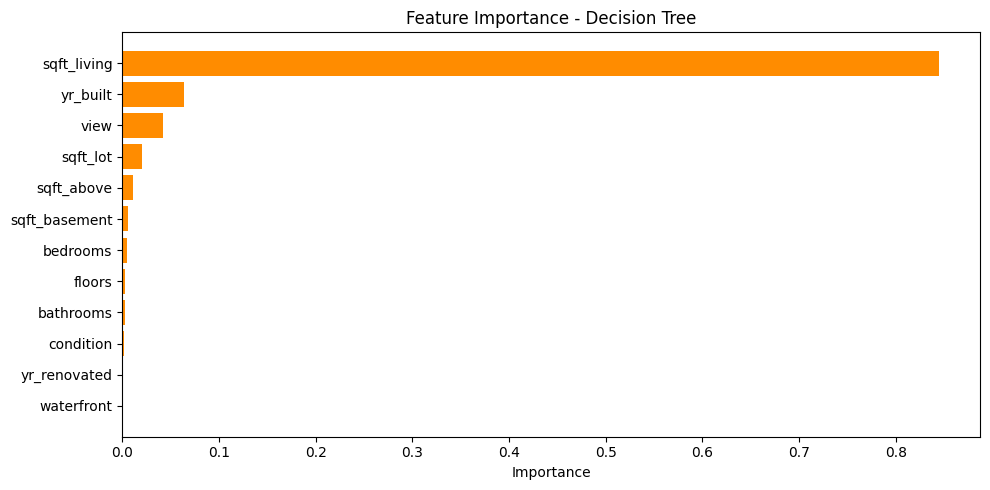

,Feature,Importance
2,sqft_living,0.845003
10,yr_built,0.063391
6,view,0.041772
3,sqft_lot,0.020778
8,sqft_above,0.011517
9,sqft_basement,0.005454
0,bedrooms,0.004378
4,floors,0.002768
1,bathrooms,0.002529
7,condition,0.001774


In [14]:
# Feature Importance
fi_df = pd.DataFrame({
    'Feature': FEATURES,
    'Importance': dt_model.feature_importances_
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(10, 5))
plt.barh(fi_df['Feature'], fi_df['Importance'], color='darkorange')
plt.title('Feature Importance - Decision Tree')
plt.xlabel('Importance')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

fi_df

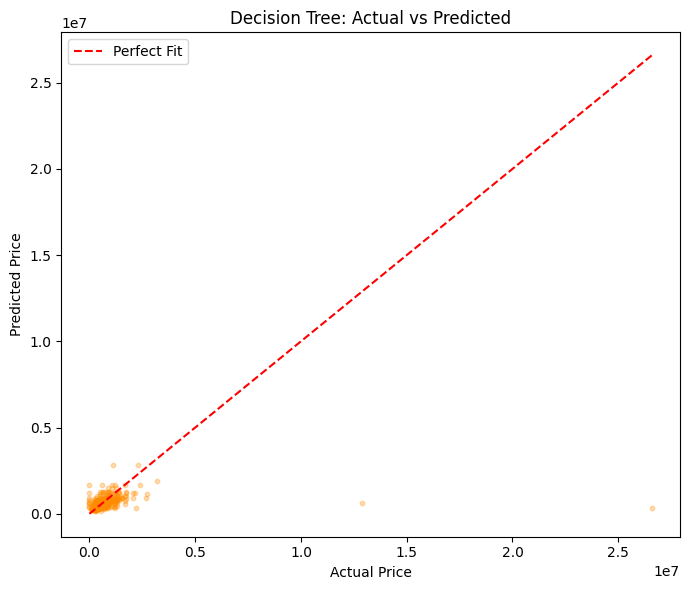

In [15]:
# Actual vs Predicted
plt.figure(figsize=(7, 6))
plt.scatter(y_test, y_pred_dt, alpha=0.3, color='darkorange', s=10)
lims = [y_test.min(), y_test.max()]
plt.plot(lims, lims, 'r--', linewidth=1.5, label='Perfect Fit')
plt.title('Decision Tree: Actual vs Predicted')
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.legend()
plt.tight_layout()
plt.show()

## 5. Perbandingan Model

                             MAE           RMSE        R2
Model                                                    
Linear Regression  210908.173250  993439.362546  0.032284
Decision Tree      213792.954748  992633.817701  0.033853


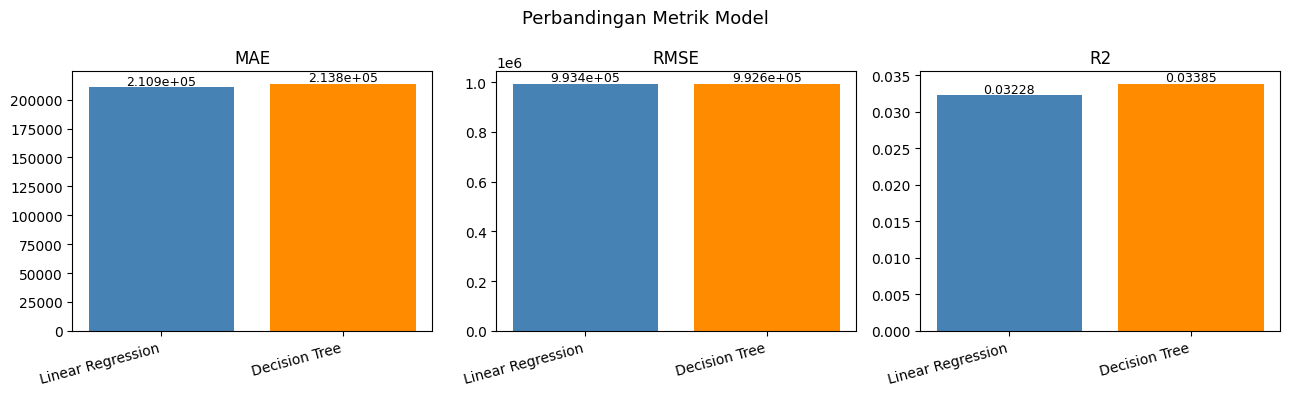

In [16]:
comparison = pd.DataFrame({
    'Model': ['Linear Regression', 'Decision Tree'],
    'MAE':   [mae_lr, mae_dt],
    'RMSE':  [rmse_lr, rmse_dt],
    'R2':    [r2_lr, r2_dt]
}).set_index('Model')
print(comparison.to_string())

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
colors = ['steelblue', 'darkorange']
for ax, metric in zip(axes, ['MAE', 'RMSE', 'R2']):
    vals = comparison[metric].values
    ax.bar(comparison.index, vals, color=colors)
    ax.set_title(metric)
    ax.set_xticklabels(comparison.index, rotation=15, ha='right')
    for i, v in enumerate(vals):
        ax.text(i, v * 1.01, f'{v:,.4g}', ha='center', fontsize=9)
plt.suptitle('Perbandingan Metrik Model', fontsize=13)
plt.tight_layout()
plt.show()

## 6. Simpan Model

In [17]:
joblib.dump(lr_model, 'model_linear_regression.pkl')
joblib.dump(dt_model, 'model_decision_tree.pkl')

print('Model tersimpan:')
print('  - model_linear_regression.pkl')
print('  - model_decision_tree.pkl')

Model tersimpan:
  - model_linear_regression.pkl
  - model_decision_tree.pkl


In [18]:
# Verifikasi: load model dan prediksi satu sampel
lr_loaded = joblib.load('model_linear_regression.pkl')
dt_loaded = joblib.load('model_decision_tree.pkl')

sample = X_test.iloc[[0]]
print(sample.to_string())
print(f'\nActual price  : {y_test.iloc[0]:,.0f}')
print(f'LR prediction : {lr_loaded.predict(sample)[0]:,.0f}')
print(f'DT prediction : {dt_loaded.predict(sample)[0]:,.0f}')

      bedrooms  bathrooms  sqft_living  sqft_lot  floors  waterfront  view  condition  sqft_above  sqft_basement  yr_built  yr_renovated
3683       3.0        2.5         1460      1613     2.0           0     0          3        1180            280      2007             0

Actual price  : 544,000
LR prediction : 304,863
DT prediction : 433,410
